In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("네이버 영화리뷰 감성분석 프로젝트 (NSMC)")
print("=" * 80)
print(f"PyTorch version: {torch.__version__}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print()

네이버 영화리뷰 감성분석 프로젝트 (NSMC)
PyTorch version: 2.7.1+cu118
Using device: cuda



In [2]:

# ============================================================================
# Step 1: 데이터 준비와 확인
# ============================================================================

print("=" * 80)
print("Step 1: 데이터 준비와 확인")
print("=" * 80)

train_path = 'ratings_train.txt'
test_path = 'ratings_test.txt'

try:
    # 데이터 로드
    print("\n[1-1] 데이터 파일 로드 중...")
    train_data = pd.read_csv(train_path, sep='\t', encoding='utf-8')
    test_data = pd.read_csv(test_path, sep='\t', encoding='utf-8')
    
    print(f"✓ 데이터 로드 완료")
    print(f"  - Train 데이터: {len(train_data):,}개")
    print(f"  - Test 데이터: {len(test_data):,}개")
    print(f"\n[Train 데이터 샘플]")
    print(train_data.head(3))
    
    # 데이터 통계
    print(f"\n[1-2] 데이터 통계 확인")
    print(f"  - Train 긍정: {sum(train_data['label']==1):,}개 ({sum(train_data['label']==1)/len(train_data)*100:.1f}%)")
    print(f"  - Train 부정: {sum(train_data['label']==0):,}개 ({sum(train_data['label']==0)/len(train_data)*100:.1f}%)")
    print(f"  - Test 긍정: {sum(test_data['label']==1):,}개 ({sum(test_data['label']==1)/len(test_data)*100:.1f}%)")
    print(f"  - Test 부정: {sum(test_data['label']==0):,}개 ({sum(test_data['label']==0)/len(test_data)*100:.1f}%)")
    
    DATA_LOADED = True
    
except FileNotFoundError:
    print("❌ 데이터 파일을 찾을 수 없습니다!")
    print("\n다음 명령어로 데이터를 다운로드하세요:")
    print("!wget https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt")
    print("!wget https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt")
    DATA_LOADED = False

Step 1: 데이터 준비와 확인

[1-1] 데이터 파일 로드 중...
✓ 데이터 로드 완료
  - Train 데이터: 150,000개
  - Test 데이터: 50,000개

[Train 데이터 샘플]
         id                           document  label
0   9976970                아 더빙.. 진짜 짜증나네요 목소리      0
1   3819312  흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나      1
2  10265843                  너무재밓었다그래서보는것을추천한다      0

[1-2] 데이터 통계 확인
  - Train 긍정: 74,827개 (49.9%)
  - Train 부정: 75,173개 (50.1%)
  - Test 긍정: 25,173개 (50.3%)
  - Test 부정: 24,827개 (49.7%)


In [3]:
# ============================================================================
# Step 2: 데이터로더 구성
# ============================================================================

if DATA_LOADED:
    print("\n" + "=" * 80)
    print("Step 2: 데이터로더 구성")
    print("=" * 80)
    
    # 2-1: 중복 제거
    print("\n[2-1] 중복 제거")
    before_train = len(train_data)
    before_test = len(test_data)
    train_data = train_data.drop_duplicates(subset=['document'])
    test_data = test_data.drop_duplicates(subset=['document'])
    print(f"  - Train: {before_train:,}개 → {len(train_data):,}개 (제거: {before_train-len(train_data):,}개)")
    print(f"  - Test: {before_test:,}개 → {len(test_data):,}개 (제거: {before_test-len(test_data):,}개)")
    
    # 2-2: NaN 결측치 제거
    print("\n[2-2] NaN 결측치 제거")
    before_train = len(train_data)
    before_test = len(test_data)
    train_data = train_data.dropna()
    test_data = test_data.dropna()
    print(f"  - Train: {before_train:,}개 → {len(train_data):,}개 (제거: {before_train-len(train_data):,}개)")
    print(f"  - Test: {before_test:,}개 → {len(test_data):,}개 (제거: {before_test-len(test_data):,}개)")
    
    # 2-3: 토크나이저 (공백 기반)
    print("\n[2-3] 토크나이저 적용 (공백 기반)")
    def simple_tokenizer(text):
        return text.split()
    
    train_tokens = [simple_tokenizer(doc) for doc in train_data['document']]
    test_tokens = [simple_tokenizer(doc) for doc in test_data['document']]
    print(f"  ✓ 토큰화 완료")
    print(f"  - 샘플: '{train_data['document'].iloc[0]}'")
    print(f"  - 토큰: {train_tokens[0]}")
    
    # 2-4: 불용어 제거
    print("\n[2-4] 불용어(Stopwords) 제거")
    stopwords = ['의', '가', '이', '은', '들', '는', '좀', '잘', '걍', '과', '도', 
                 '를', '으로', '자', '에', '와', '한', '하다']
    
    def remove_stopwords(tokens):
        return [token for token in tokens if token not in stopwords and len(token) > 1]
    
    before_len = len(train_tokens[0])
    train_tokens = [remove_stopwords(tokens) for tokens in train_tokens]
    test_tokens = [remove_stopwords(tokens) for tokens in test_tokens]
    after_len = len(train_tokens[0])
    print(f"  ✓ 불용어 제거 완료")
    print(f"  - 불용어 개수: {len(stopwords)}개")
    print(f"  - 샘플 토큰 변화: {before_len}개 → {after_len}개")
    print(f"  - 제거 후: {train_tokens[0]}")
    
    # 2-5: 단어 사전 구성
    print("\n[2-5] 단어 사전(word_to_index) 구성")
    num_words = 10000
    all_words = []
    for tokens in train_tokens:
        all_words.extend(tokens)
    
    word_counts = Counter(all_words)
    print(f"  - 전체 단어 수: {len(word_counts):,}개")
    print(f"  - 총 단어 빈도: {sum(word_counts.values()):,}개")
    
    # 빈도수 상위 num_words개만 사용
    most_common_words = word_counts.most_common(num_words - 2)
    vocab = [word for word, count in most_common_words]
    
    # word_to_index 딕셔너리 생성
    word_to_index = {}
    word_to_index['<PAD>'] = 0
    word_to_index['<UNK>'] = 1
    for idx, word in enumerate(vocab):
        word_to_index[word] = idx + 2
    
    # index_to_word
    index_to_word = {idx: word for word, idx in word_to_index.items()}
    
    print(f"  ✓ 단어 사전 구성 완료")
    print(f"  - 사전 크기(vocab_size): {len(word_to_index):,}개")
    print(f"  - 상위 10개 단어: {vocab[:10]}")
    print(f"  - <PAD> 인덱스: {word_to_index['<PAD>']}")
    print(f"  - <UNK> 인덱스: {word_to_index['<UNK>']}")
    
    # 2-6: 텍스트를 인덱스로 변환
    print("\n[2-6] 텍스트를 인덱스로 변환")
    def tokens_to_indices(tokens, word_to_index):
        return [word_to_index.get(token, word_to_index['<UNK>']) for token in tokens]
    
    X_train = [tokens_to_indices(tokens, word_to_index) for tokens in train_tokens]
    X_test = [tokens_to_indices(tokens, word_to_index) for tokens in test_tokens]
    y_train = train_data['label'].values
    y_test = test_data['label'].values
    
    print(f"  ✓ 인덱스 변환 완료")
    print(f"  - X_train[0] 샘플 (처음 10개): {X_train[0][:10]}")
    print(f"  - y_train[0]: {y_train[0]}")
    
    # 2-7: 변환 확인
    print("\n[2-7] 인덱스 → 텍스트 디코딩 테스트")
    decoded = ' '.join([index_to_word[idx] for idx in X_train[0]])
    print(f"  - 원본: {train_data['document'].iloc[0]}")
    print(f"  - 디코딩: {decoded}")
    print(f"  - 라벨: {y_train[0]} ({'긍정' if y_train[0]==1 else '부정'})")
    
    print(f"\n✓ Step 2 완료!")
    print(f"  - X_train: {len(X_train):,}개")
    print(f"  - y_train: {len(y_train):,}개")
    print(f"  - X_test: {len(X_test):,}개")
    print(f"  - y_test: {len(y_test):,}개")
    print(f"  - Vocabulary size: {len(word_to_index):,}개")



Step 2: 데이터로더 구성

[2-1] 중복 제거
  - Train: 150,000개 → 146,183개 (제거: 3,817개)
  - Test: 50,000개 → 49,158개 (제거: 842개)

[2-2] NaN 결측치 제거
  - Train: 146,183개 → 146,182개 (제거: 1개)
  - Test: 49,158개 → 49,157개 (제거: 1개)

[2-3] 토크나이저 적용 (공백 기반)
  ✓ 토큰화 완료
  - 샘플: '아 더빙.. 진짜 짜증나네요 목소리'
  - 토큰: ['아', '더빙..', '진짜', '짜증나네요', '목소리']

[2-4] 불용어(Stopwords) 제거
  ✓ 불용어 제거 완료
  - 불용어 개수: 18개
  - 샘플 토큰 변화: 5개 → 4개
  - 제거 후: ['더빙..', '진짜', '짜증나네요', '목소리']

[2-5] 단어 사전(word_to_index) 구성
  - 전체 단어 수: 356,830개
  - 총 단어 빈도: 1,059,766개
  ✓ 단어 사전 구성 완료
  - 사전 크기(vocab_size): 10,000개
  - 상위 10개 단어: ['영화', '너무', '정말', '진짜', '영화.', '이런', '그냥', '영화를', '보고', '영화가']
  - <PAD> 인덱스: 0
  - <UNK> 인덱스: 1

[2-6] 텍스트를 인덱스로 변환
  ✓ 인덱스 변환 완료
  - X_train[0] 샘플 (처음 10개): [1, 5, 1, 968]
  - y_train[0]: 0

[2-7] 인덱스 → 텍스트 디코딩 테스트
  - 원본: 아 더빙.. 진짜 짜증나네요 목소리
  - 디코딩: <UNK> 진짜 <UNK> 목소리
  - 라벨: 0 (부정)

✓ Step 2 완료!
  - X_train: 146,182개
  - y_train: 146,182개
  - X_test: 49,157개
  - y_test: 49,157개
  - Vocabulary size: 10,000개



Step 3: 모델 구성을 위한 데이터 분석 및 가공

[3-1] 데이터셋 내 문장 길이 분포
  - Train 평균 길이: 7.25
  - Train 중간값: 5
  - Train 최소/최대: 0 / 37
  - Test 평균 길이: 7.22
  - Test 중간값: 5
  - Test 최소/최대: 0 / 35

  [백분위수 분석]
    - 50%: 5개 단어
    - 75%: 9개 단어
    - 90%: 15개 단어
    - 95%: 22개 단어
    - 99%: 29개 단어

[3-2] 적절한 최대 문장 길이 지정
  ✓ 선택된 maxlen: 22 (95% 백분위수)

[3-3] 문장 길이 분포 시각화
  ✓ 그래프 저장: step3_sentence_length.png


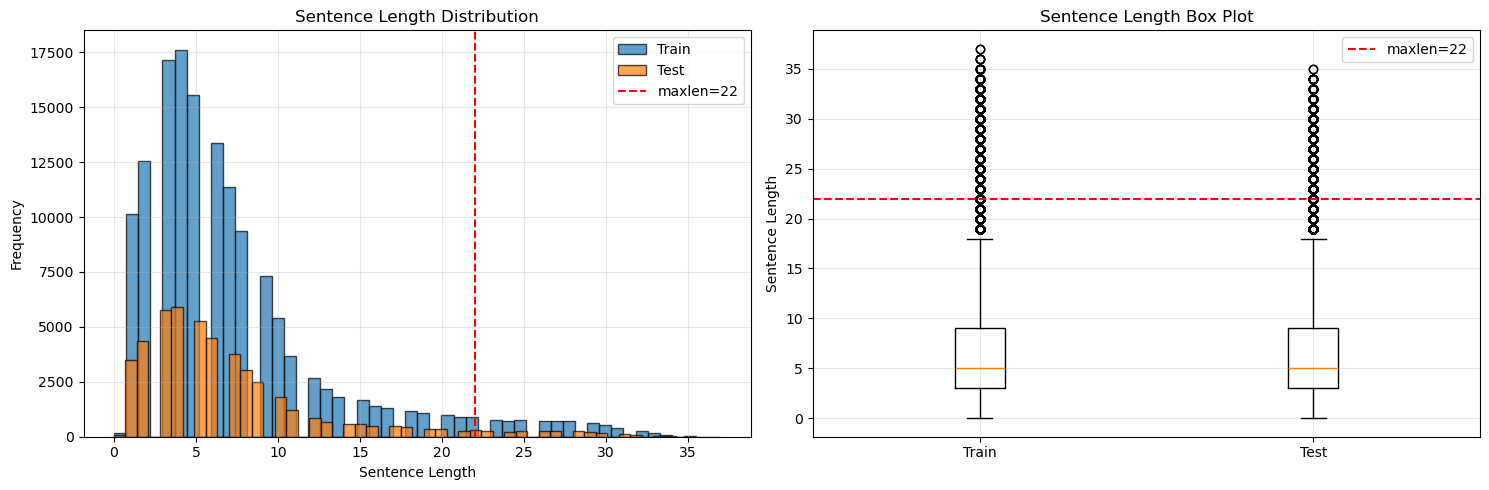


[3-4] 문장 자르기

✓ Step 3 완료!
  - maxlen: 22


In [4]:
# ============================================================================
# Step 3: 모델 구성을 위한 데이터 분석 및 가공
# ============================================================================

if DATA_LOADED:
    print("\n" + "=" * 80)
    print("Step 3: 모델 구성을 위한 데이터 분석 및 가공")
    print("=" * 80)
    
    # 3-1: 문장 길이 분포 분석
    print("\n[3-1] 데이터셋 내 문장 길이 분포")
    train_lengths = [len(x) for x in X_train]
    test_lengths = [len(x) for x in X_test]
    
    print(f"  - Train 평균 길이: {np.mean(train_lengths):.2f}")
    print(f"  - Train 중간값: {np.median(train_lengths):.0f}")
    print(f"  - Train 최소/최대: {np.min(train_lengths)} / {np.max(train_lengths)}")
    print(f"  - Test 평균 길이: {np.mean(test_lengths):.2f}")
    print(f"  - Test 중간값: {np.median(test_lengths):.0f}")
    print(f"  - Test 최소/최대: {np.min(test_lengths)} / {np.max(test_lengths)}")
    
    # 백분위수
    print(f"\n  [백분위수 분석]")
    for percentile in [50, 75, 90, 95, 99]:
        value = np.percentile(train_lengths, percentile)
        print(f"    - {percentile}%: {value:.0f}개 단어")
    
    # 3-2: 최대 길이 설정
    print("\n[3-2] 적절한 최대 문장 길이 지정")
    maxlen = int(np.percentile(train_lengths, 95))
    print(f"  ✓ 선택된 maxlen: {maxlen} (95% 백분위수)")
    
    # 3-3: 시각화
    print("\n[3-3] 문장 길이 분포 시각화")
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    axes[0].hist(train_lengths, bins=50, alpha=0.7, label='Train', edgecolor='black')
    axes[0].hist(test_lengths, bins=50, alpha=0.7, label='Test', edgecolor='black')
    axes[0].axvline(maxlen, color='r', linestyle='--', label=f'maxlen={maxlen}')
    axes[0].set_xlabel('Sentence Length')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Sentence Length Distribution')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].boxplot([train_lengths, test_lengths], labels=['Train', 'Test'])
    axes[1].axhline(maxlen, color='r', linestyle='--', label=f'maxlen={maxlen}')
    axes[1].set_ylabel('Sentence Length')
    axes[1].set_title('Sentence Length Box Plot')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('step3_sentence_length.png', dpi=300, bbox_inches='tight')
    print(f"  ✓ 그래프 저장: step3_sentence_length.png")
    plt.show()
    
    # 3-4: 패딩
    print("\n[3-4] 문장 자르기")
    X_train = [x[:maxlen] if len(x) > maxlen else x for x in X_train]
    X_test = [x[:maxlen] if len(x) > maxlen else x for x in X_test]
    
    print(f"\n✓ Step 3 완료!")
    print(f"  - maxlen: {maxlen}")

In [5]:
# ============================================================================
# Step 4: 모델 구성 및 validation set 구성
# ============================================================================

from torch.utils.data import random_split

class NSMCDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return torch.LongTensor(self.X[idx]), torch.LongTensor([self.y[idx]])


def collate_fn(batch):
    X_batch, y_batch = zip(*batch)
    X_padded = pad_sequence(X_batch, batch_first=True, padding_value=0)
    y_batch = torch.cat(y_batch)
    return X_padded, y_batch


class SimpleRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers=1, dropout=0.3):
        super(SimpleRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.rnn = nn.RNN(embedding_dim, hidden_dim, n_layers, 
                          batch_first=True, dropout=dropout if n_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        output, hidden = self.rnn(embedded)
        hidden = self.dropout(hidden[-1])
        return self.fc(hidden)


class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers=2, dropout=0.3):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, n_layers,
                           batch_first=True, dropout=dropout if n_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        output, (hidden, cell) = self.lstm(embedded)
        hidden = self.dropout(hidden[-1])
        return self.fc(hidden)


class BiLSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers=2, dropout=0.3):
        super(BiLSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, n_layers,
                           batch_first=True, dropout=dropout if n_layers > 1 else 0,
                           bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        output, (hidden, cell) = self.lstm(embedded)
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        hidden = self.dropout(hidden)
        return self.fc(hidden)


class GRUModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers=2, dropout=0.3):
        super(GRUModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.gru = nn.GRU(embedding_dim, hidden_dim, n_layers,
                         batch_first=True, dropout=dropout if n_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        output, hidden = self.gru(embedded)
        hidden = self.dropout(hidden[-1])
        return self.fc(hidden)


if DATA_LOADED:
    print("\n" + "=" * 80)
    print("Step 4: 모델 구성 및 validation set 구성")
    print("=" * 80)
    
    # Dataset 생성
    print("\n[4-1] Dataset 생성")
    train_dataset = NSMCDataset(X_train, y_train)
    test_dataset = NSMCDataset(X_test, y_test)
    print(f"  ✓ Train Dataset: {len(train_dataset):,}개")
    print(f"  ✓ Test Dataset: {len(test_dataset):,}개")
    
    # Validation set 분리
    print("\n[4-2] Validation set 구성")
    validation_split = 10000
    train_size = len(train_dataset) - validation_split
    val_size = validation_split
    
    train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])
    
    print(f"  ✓ Train set: {len(train_dataset):,}개")
    print(f"  ✓ Validation set: {len(val_dataset):,}개")
    print(f"  ✓ Test set: {len(test_dataset):,}개")
    
    # DataLoader 생성
    print("\n[4-3] DataLoader 생성")
    batch_size = 64
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
    
    print(f"  ✓ Batch size: {batch_size}")
    print(f"  ✓ Train batches: {len(train_loader):,}개")
    print(f"  ✓ Validation batches: {len(val_loader):,}개")
    print(f"  ✓ Test batches: {len(test_loader):,}개")
    
    # 모델 생성
    print("\n[4-4] 모델 구성 (4가지 모델)")
    vocab_size = len(word_to_index)
    embedding_dim = 128
    hidden_dim = 256
    output_dim = 1
    
    models = {
        'SimpleRNN': SimpleRNN(vocab_size, embedding_dim, hidden_dim, output_dim),
        'LSTM': LSTMModel(vocab_size, embedding_dim, hidden_dim, output_dim),
        'BiLSTM': BiLSTMModel(vocab_size, embedding_dim, hidden_dim, output_dim),
        'GRU': GRUModel(vocab_size, embedding_dim, hidden_dim, output_dim)
    }
    
    print(f"  ✓ 생성된 모델:")
    for name, model in models.items():
        num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"    - {name}: {num_params:,}개 파라미터")
    
    print(f"\n  [모델 하이퍼파라미터]")
    print(f"    - Vocabulary size: {vocab_size:,}")
    print(f"    - Embedding dim: {embedding_dim}")
    print(f"    - Hidden dim: {hidden_dim}")
    
    print(f"\n✓ Step 4 완료!")



Step 4: 모델 구성 및 validation set 구성

[4-1] Dataset 생성
  ✓ Train Dataset: 146,182개
  ✓ Test Dataset: 49,157개

[4-2] Validation set 구성
  ✓ Train set: 136,182개
  ✓ Validation set: 10,000개
  ✓ Test set: 49,157개

[4-3] DataLoader 생성
  ✓ Batch size: 64
  ✓ Train batches: 2,128개
  ✓ Validation batches: 157개
  ✓ Test batches: 769개

[4-4] 모델 구성 (4가지 모델)
  ✓ 생성된 모델:
    - SimpleRNN: 1,379,073개 파라미터
    - LSTM: 2,201,857개 파라미터
    - BiLSTM: 3,648,001개 파라미터
    - GRU: 1,971,457개 파라미터

  [모델 하이퍼파라미터]
    - Vocabulary size: 10,000
    - Embedding dim: 128
    - Hidden dim: 256

✓ Step 4 완료!


In [6]:
# ============================================================================
# Step 5: 모델 훈련 개시
# ============================================================================

def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    epoch_loss = 0
    epoch_acc = 0
    
    for X_batch, y_batch in dataloader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        predictions = model(X_batch).squeeze(1)
        loss = criterion(predictions, y_batch.float())
        
        rounded_preds = torch.round(torch.sigmoid(predictions))
        correct = (rounded_preds == y_batch).float()
        acc = correct.sum() / len(correct)
        
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        epoch_acc += acc.item()
    
    return epoch_loss / len(dataloader), epoch_acc / len(dataloader)


def evaluate(model, dataloader, criterion, device):
    model.eval()
    epoch_loss = 0
    epoch_acc = 0
    
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            predictions = model(X_batch).squeeze(1)
            loss = criterion(predictions, y_batch.float())
            
            rounded_preds = torch.round(torch.sigmoid(predictions))
            correct = (rounded_preds == y_batch).float()
            acc = correct.sum() / len(correct)
            
            epoch_loss += loss.item()
            epoch_acc += acc.item()
    
    return epoch_loss / len(dataloader), epoch_acc / len(dataloader)


if DATA_LOADED:
    print("\n" + "=" * 80)
    print("Step 5: 모델 훈련 개시")
    print("=" * 80)
    
    num_epochs = 20
    print(f"\n[훈련 설정]")
    print(f"  - Epochs: {num_epochs}")
    print(f"  - Optimizer: Adam")
    print(f"  - Learning rate: 0.0001")
    print(f"  - Device: {device}")
    
    histories = {}
    
    for model_name, model in models.items():
        print(f"\n{'='*80}")
        print(f"Training {model_name}")
        print(f"{'='*80}")
        
        model = model.to(device)
        criterion = nn.BCEWithLogitsLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.0001)
        
        train_losses = []
        train_accs = []
        val_losses = []
        val_accs = []
        
        best_val_acc = 0
        
        for epoch in range(num_epochs):
            train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
            val_loss, val_acc = evaluate(model, val_loader, criterion, device)
            
            train_losses.append(train_loss)
            train_accs.append(train_acc)
            val_losses.append(val_loss)
            val_accs.append(val_acc)
            
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                torch.save(model.state_dict(), f'best_{model_name}.pt')
            
            if (epoch + 1) % 5 == 0:
                print(f'Epoch {epoch+1:02d}/{num_epochs}')
                print(f'  Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%')
                print(f'  Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%')
        
        print(f'\n✓ Best Validation Accuracy: {best_val_acc*100:.2f}%')
        
        histories[model_name] = {
            'train_loss': train_losses,
            'train_acc': train_accs,
            'val_loss': val_losses,
            'val_acc': val_accs,
            'best_val_acc': best_val_acc
        }
    
    print(f"\n✓ Step 5 완료!")
    print(f"\n[모든 모델 Best Validation Accuracy]")
    for name, history in histories.items():
        print(f"  - {name}: {history['best_val_acc']*100:.2f}%")


Step 5: 모델 훈련 개시

[훈련 설정]
  - Epochs: 20
  - Optimizer: Adam
  - Learning rate: 0.0001
  - Device: cuda

Training SimpleRNN
Epoch 05/20
  Train Loss: 0.5959 | Train Acc: 66.80%
  Val Loss: 0.5619 | Val Acc: 69.07%
Epoch 10/20
  Train Loss: 0.5219 | Train Acc: 72.32%
  Val Loss: 0.5089 | Val Acc: 73.17%
Epoch 15/20
  Train Loss: 0.4845 | Train Acc: 74.56%
  Val Loss: 0.4817 | Val Acc: 75.04%
Epoch 20/20
  Train Loss: 0.4619 | Train Acc: 75.93%
  Val Loss: 0.4770 | Val Acc: 75.62%

✓ Best Validation Accuracy: 75.62%

Training LSTM
Epoch 05/20
  Train Loss: 0.5176 | Train Acc: 71.99%
  Val Loss: 0.5000 | Val Acc: 73.14%
Epoch 10/20
  Train Loss: 0.4762 | Train Acc: 74.71%
  Val Loss: 0.4750 | Val Acc: 74.95%
Epoch 15/20
  Train Loss: 0.4488 | Train Acc: 76.38%
  Val Loss: 0.4624 | Val Acc: 76.10%
Epoch 20/20
  Train Loss: 0.4282 | Train Acc: 77.54%
  Val Loss: 0.4647 | Val Acc: 76.14%

✓ Best Validation Accuracy: 76.15%

Training BiLSTM
Epoch 05/20
  Train Loss: 0.5113 | Train Acc: 72.49


Step 6: Loss, Accuracy 그래프 시각화
  ✓ 그래프 저장: step6_training_history.png


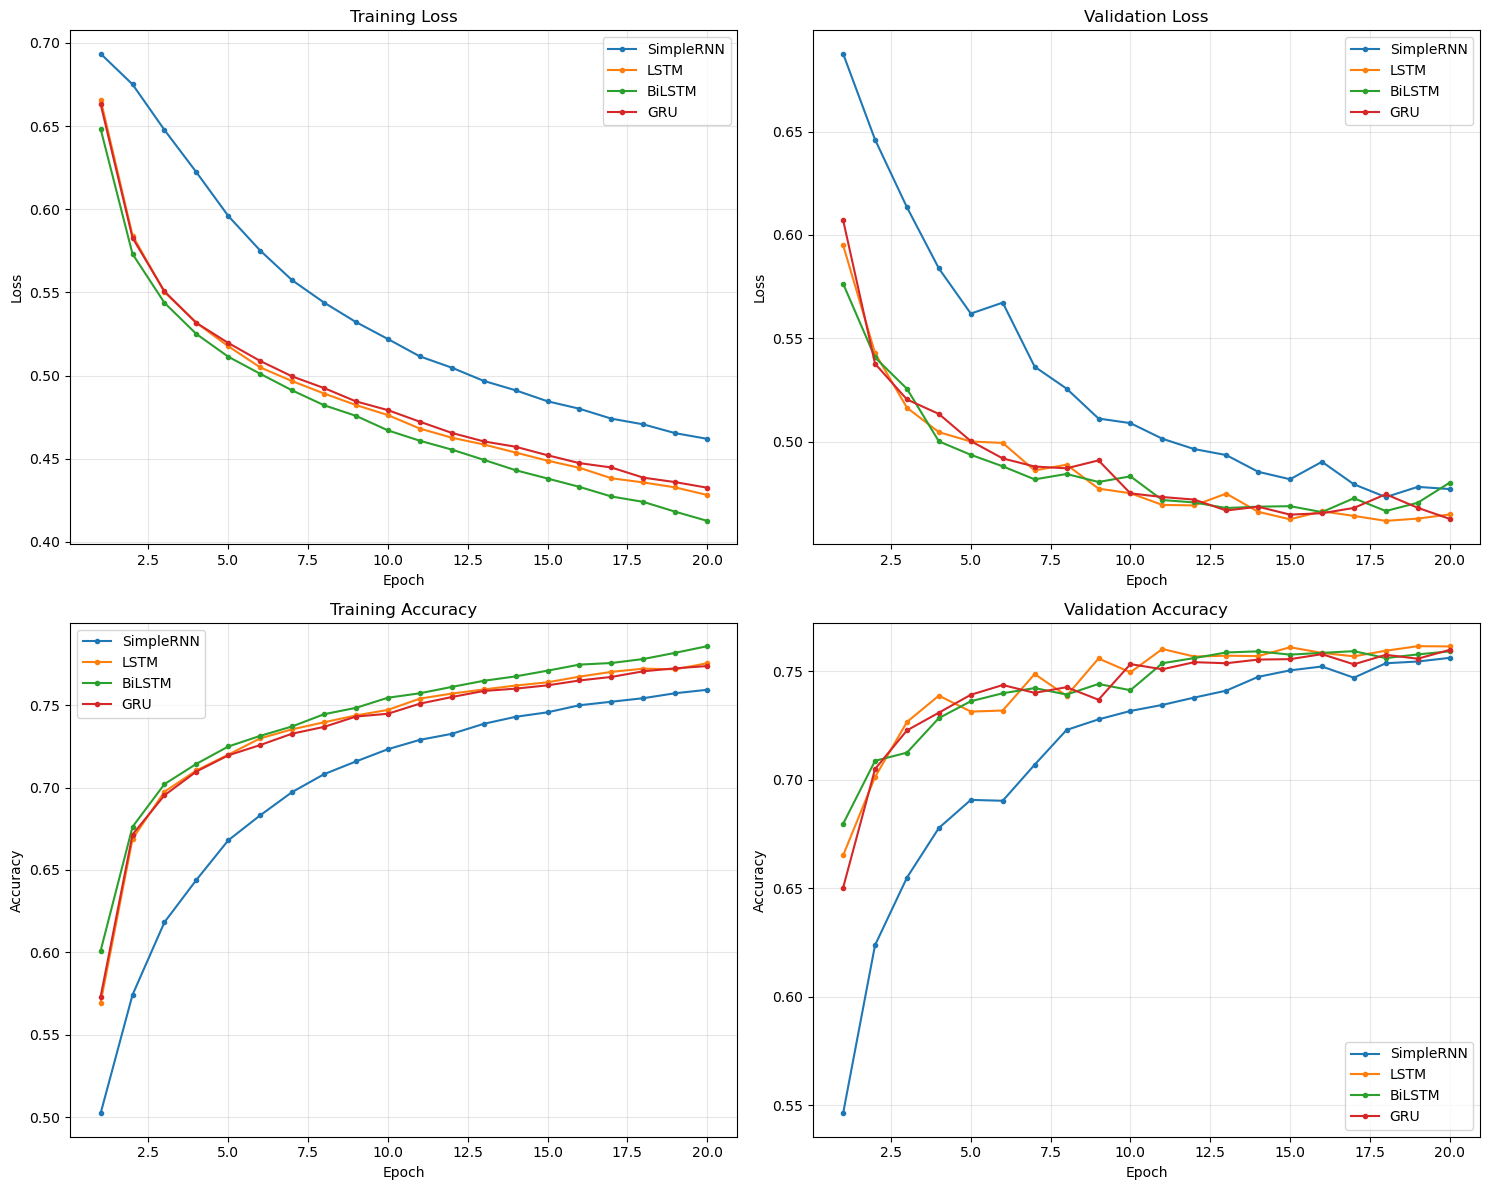


✓ Step 6 완료!


In [7]:
# ============================================================================
# Step 6: Loss, Accuracy 그래프 시각화
# ============================================================================

if DATA_LOADED:
    print("\n" + "=" * 80)
    print("Step 6: Loss, Accuracy 그래프 시각화")
    print("=" * 80)
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    for model_name, history in histories.items():
        epochs = range(1, len(history['train_loss']) + 1)
        
        axes[0, 0].plot(epochs, history['train_loss'], label=f'{model_name}', marker='o', markersize=3)
        axes[0, 1].plot(epochs, history['val_loss'], label=f'{model_name}', marker='o', markersize=3)
        axes[1, 0].plot(epochs, history['train_acc'], label=f'{model_name}', marker='o', markersize=3)
        axes[1, 1].plot(epochs, history['val_acc'], label=f'{model_name}', marker='o', markersize=3)
    
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Training Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].set_title('Validation Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Accuracy')
    axes[1, 0].set_title('Training Accuracy')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Accuracy')
    axes[1, 1].set_title('Validation Accuracy')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('step6_training_history.png', dpi=300, bbox_inches='tight')
    print(f"  ✓ 그래프 저장: step6_training_history.png")
    plt.show()
    
    print(f"\n✓ Step 6 완료!")


Step 7: 학습된 Embedding 레이어 분석

[Test Set 평가]
  SimpleRNN      : 75.27%
  LSTM           : 75.74%
  BiLSTM         : 75.64%
  GRU            : 75.70%

  ✓ Best Model: LSTM

[7-1] Embedding 정보
  - Embedding shape: (10000, 128)
  - Vocabulary size: 10,000
  - Embedding dimension: 128

[7-2] 주요 단어 임베딩 시각화 (PCA)
  ✓ PCA 시각화 저장: step7_embedding_pca.png


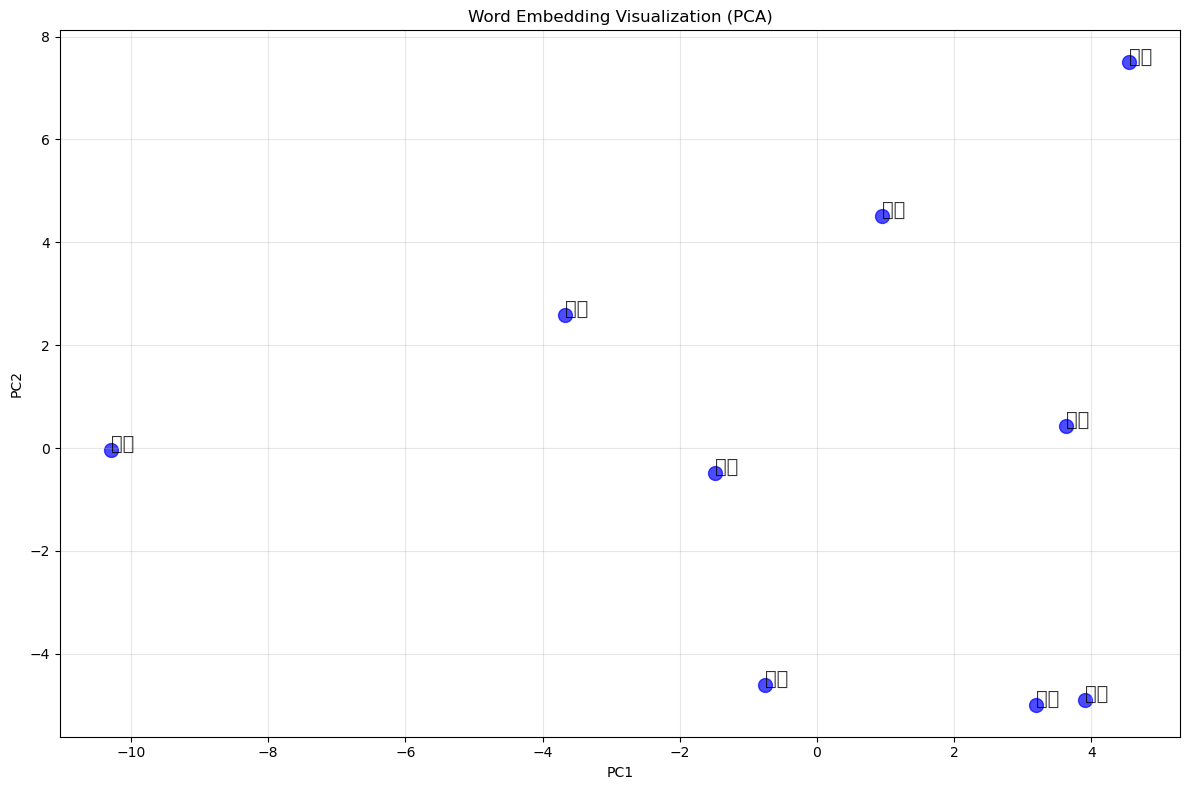


[7-3] 단어 유사도 분석 (Cosine Similarity)

  '영화'와 유사한 단어 Top 5:
    - 우선: 0.3426
    - 애잔한: 0.2953
    - .....: 0.2814
    - 진실된: 0.2756
    - 작품도: 0.2717

  '재미'와 유사한 단어 Top 5:
    - 없는..: 0.3557
    - 여친이랑: 0.3288
    - 글구: 0.3037
    - 네이버에: 0.3021
    - 전개나: 0.2920

  '최악'와 유사한 단어 Top 5:
    - 존내: 0.3171
    - 세상: 0.3057
    - 미국식: 0.2980
    - 잔인한: 0.2957
    - 무지: 0.2933

✓ Step 7 완료!


In [8]:
# ============================================================================
# Step 7: 학습된 Embedding 레이어 분석
# ============================================================================

if DATA_LOADED:
    print("\n" + "=" * 80)
    print("Step 7: 학습된 Embedding 레이어 분석")
    print("=" * 80)
    
    # Test set 평가하여 best model 찾기
    print("\n[Test Set 평가]")
    test_results = {}
    for model_name, model in models.items():
        model.load_state_dict(torch.load(f'best_{model_name}.pt'))
        criterion = nn.BCEWithLogitsLoss()
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)
        test_results[model_name] = test_acc
        print(f"  {model_name:15s}: {test_acc*100:.2f}%")
    
    best_model_name = max(test_results, key=test_results.get)
    print(f"\n  ✓ Best Model: {best_model_name}")
    
    best_model = models[best_model_name]
    best_model.load_state_dict(torch.load(f'best_{best_model_name}.pt'))
    
    embedding_matrix = best_model.embedding.weight.data.cpu().numpy()
    
    print(f"\n[7-1] Embedding 정보")
    print(f"  - Embedding shape: {embedding_matrix.shape}")
    print(f"  - Vocabulary size: {len(word_to_index):,}")
    print(f"  - Embedding dimension: {embedding_matrix.shape[1]}")
    
    # 단어 임베딩 시각화
    print(f"\n[7-2] 주요 단어 임베딩 시각화 (PCA)")
    common_words = ['영화', '정말', '재미', '최고', '별로', '최악', '감동', '추천', '좋다', '나쁘다']
    
    word_vectors = []
    word_labels = []
    
    for word in common_words:
        if word in word_to_index:
            idx = word_to_index[word]
            word_vectors.append(embedding_matrix[idx])
            word_labels.append(word)
    
    if len(word_vectors) > 1:
        word_vectors = np.array(word_vectors)
        
        from sklearn.decomposition import PCA
        pca = PCA(n_components=2)
        word_vectors_2d = pca.fit_transform(word_vectors)
        
        plt.figure(figsize=(12, 8))
        plt.scatter(word_vectors_2d[:, 0], word_vectors_2d[:, 1], s=100, alpha=0.7, c='blue')
        
        for i, word in enumerate(word_labels):
            plt.annotate(word, (word_vectors_2d[i, 0], word_vectors_2d[i, 1]),
                        fontsize=14, alpha=0.8, fontweight='bold')
        
        plt.xlabel('PC1')
        plt.ylabel('PC2')
        plt.title('Word Embedding Visualization (PCA)')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('step7_embedding_pca.png', dpi=300, bbox_inches='tight')
        print(f"  ✓ PCA 시각화 저장: step7_embedding_pca.png")
        plt.show()
    
    # 코사인 유사도
    print(f"\n[7-3] 단어 유사도 분석 (Cosine Similarity)")
    
    def cosine_similarity(vec1, vec2):
        dot_product = np.dot(vec1, vec2)
        norm1 = np.linalg.norm(vec1)
        norm2 = np.linalg.norm(vec2)
        return dot_product / (norm1 * norm2) if norm1 * norm2 != 0 else 0
    
    test_words = ['영화', '재미', '최악']
    for word in test_words:
        if word in word_to_index:
            word_idx = word_to_index[word]
            word_vec = embedding_matrix[word_idx]
            
            similarities = []
            for idx in range(2, len(embedding_matrix)):
                if idx != word_idx:
                    sim = cosine_similarity(word_vec, embedding_matrix[idx])
                    similarities.append((idx, sim))
            
            similarities.sort(key=lambda x: x[1], reverse=True)
            
            print(f"\n  '{word}'와 유사한 단어 Top 5:")
            for idx, sim in similarities[:5]:
                similar_word = index_to_word.get(idx, '<UNK>')
                print(f"    - {similar_word}: {sim:.4f}")
    
    print(f"\n✓ Step 7 완료!")

In [9]:
# ============================================================================
# Step 8: 한국어 Word2Vec 임베딩 활용
# ============================================================================

class LSTMWithWord2Vec(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, 
                 pretrained_embeddings=None, n_layers=2, dropout=0.3):
        super(LSTMWithWord2Vec, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        if pretrained_embeddings is not None:
            self.embedding.weight.data.copy_(torch.from_numpy(pretrained_embeddings))
        
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, n_layers,
                           batch_first=True, dropout=dropout if n_layers > 1 else 0,
                           bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        output, (hidden, cell) = self.lstm(embedded)
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        hidden = self.dropout(hidden)
        return self.fc(hidden)


if DATA_LOADED:
    print("\n" + "=" * 80)
    print("Step 8: 한국어 Word2Vec 임베딩 활용")
    print("=" * 80)
    
    word2vec_path = '/data/word2vec_ko.model'
    
    print(f"\n[8-1] Word2Vec 모델 로드 시도")
    print(f"  - 경로: {word2vec_path}")
    
    try:
        from gensim.models import Word2Vec
        word2vec_model = Word2Vec.load(word2vec_path)
        
        print(f"  ✓ Word2Vec 모델 로드 완료")
        print(f"  - Vocabulary size: {len(word2vec_model.wv):,}")
        print(f"  - Embedding dimension: {word2vec_model.wv.vector_size}")
        
        # 임베딩 매트릭스 생성
        print(f"\n[8-2] 사전훈련된 임베딩 매트릭스 생성")
        embedding_matrix = np.random.randn(vocab_size, embedding_dim) * 0.01
        
        found_words = 0
        for word, idx in word_to_index.items():
            if word in word2vec_model.wv:
                embedding_matrix[idx] = word2vec_model.wv[word]
                found_words += 1
        
        print(f"  ✓ 발견된 단어: {found_words:,}/{vocab_size:,} ({found_words/vocab_size*100:.2f}%)")
        
        # 모델 학습
        print(f"\n[8-3] Word2Vec 임베딩 모델 학습")
        
        model_w2v = LSTMWithWord2Vec(
            vocab_size, embedding_dim, hidden_dim, output_dim,
            pretrained_embeddings=embedding_matrix
        ).to(device)
        
        criterion = nn.BCEWithLogitsLoss()
        optimizer = optim.Adam(model_w2v.parameters(), lr=0.0001)
        
        best_val_acc = 0
        
        for epoch in range(num_epochs):
            train_loss, train_acc = train_epoch(model_w2v, train_loader, criterion, optimizer, device)
            val_loss, val_acc = evaluate(model_w2v, val_loader, criterion, device)
            
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                torch.save(model_w2v.state_dict(), 'best_BiLSTM_Word2Vec.pt')
            
            if (epoch + 1) % 5 == 0:
                print(f'  Epoch {epoch+1:02d}/{num_epochs}')
                print(f'    Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%')
                print(f'    Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%')
        
        print(f'\n  ✓ Best Val Accuracy: {best_val_acc*100:.2f}%')
        
        # Test 평가
        model_w2v.load_state_dict(torch.load('best_BiLSTM_Word2Vec.pt'))
        test_loss, test_acc = evaluate(model_w2v, test_loader, criterion, device)
        print(f"\n[8-4] Test Accuracy: {test_acc*100:.2f}%")
        
        improvement = test_acc - test_results[best_model_name]
        print(f"  ✓ 성능 향상: {improvement*100:+.2f}%")
        
        print(f"\n✓ Step 8 완료!")
        
    except:
        print(f"  ❌ Word2Vec 파일을 찾을 수 없습니다")
        print(f"  Word2Vec 없이 Step 8을 건너뜁니다")


Step 8: 한국어 Word2Vec 임베딩 활용

[8-1] Word2Vec 모델 로드 시도
  - 경로: /data/word2vec_ko.model
  ❌ Word2Vec 파일을 찾을 수 없습니다
  Word2Vec 없이 Step 8을 건너뜁니다


In [10]:
# ============================================================================
# 최종 요약
# ============================================================================

if DATA_LOADED:
    print("\n" + "=" * 80)
    print("최종 결과 요약")
    print("=" * 80)
    
    print("\n[기본 모델 Test Accuracy]")
    for model_name in sorted(test_results, key=test_results.get, reverse=True):
        print(f"  {model_name:15s}: {test_results[model_name]*100:.2f}%")
    
    print("\n" + "=" * 80)
    print("모든 단계 완료!")
    print("=" * 80)
    print("\n생성된 파일:")
    print("  - step3_sentence_length.png")
    print("  - step6_training_history.png")
    print("  - step7_embedding_pca.png")
    print("  - best_*.pt (모델 체크포인트)")
    print("=" * 80)


최종 결과 요약

[기본 모델 Test Accuracy]
  LSTM           : 75.74%
  GRU            : 75.70%
  BiLSTM         : 75.64%
  SimpleRNN      : 75.27%

모든 단계 완료!

생성된 파일:
  - step3_sentence_length.png
  - step6_training_history.png
  - step7_embedding_pca.png
  - best_*.pt (모델 체크포인트)


In [11]:
ls

Mecab-ko-for-Google-Colab/  best_LSTM.pt       step3_sentence_length.png
NSMC.ipynb                  best_SimpleRNN.pt  step6_training_history.png
Untitled.ipynb              data/              step7_embedding_pca.png
best_BiLSTM.pt              ratings_test.txt   work/
best_GRU.pt                 ratings_train.txt
